### Loading the dataset


In [1]:
# Load the toxicity dataset and do quick inspection
import pandas as pd

file_path = "data.csv"
df = pd.read_csv(file_path, encoding="ascii")

print(df.head())
print(df.shape)
print(df.columns[:25])
print(df.columns[-10:])

   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_dEpsilon_C  MDEO-22     Class  
0      

In [2]:
import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv('data.csv')

# Initial inspection
print("Data Shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nData Info:")
print(df.info())

# Check for missing values
print("\nMissing Values:")
print(df.isnull().sum().sum())

# Check class distribution
if 'Class' in df.columns:
    print("\nClass Distribution:")
    print(df['Class'].value_counts())
else:
    print("\n'Class' column not found. Available columns:")
    print(df.columns.tolist())

Data Shape: (171, 1204)

First 5 rows:
   MATS3v  nHBint10  MATS3s  MATS3p  nHBDon_Lipinski  minHBint8  MATS3e  \
0  0.0908         0  0.0075  0.0173                0        0.0 -0.0436   
1  0.0213         0  0.1144 -0.0410                0        0.0  0.1231   
2  0.0018         0 -0.0156 -0.0765                2        0.0 -0.1138   
3 -0.0251         0 -0.0064 -0.0894                3        0.0 -0.0747   
4  0.0135         0  0.0424 -0.0353                0        0.0 -0.0638   

   MATS3c  minHBint2  MATS3m  ...   WTPT-4   WTPT-5  ETA_EtaP_L  ETA_EtaP_F  \
0  0.0409        0.0  0.1368  ...   0.0000   0.0000      0.1780      1.5488   
1 -0.0316        0.0  0.1318  ...   8.8660  19.3525      0.1739      1.3718   
2 -0.1791        0.0  0.0615  ...   5.2267  27.8796      0.1688      1.4395   
3 -0.1151        0.0  0.0361  ...   7.7896  24.7336      0.1702      1.4654   
4  0.0307        0.0  0.0306  ...  12.3240  19.7486      0.1789      1.4495   

   ETA_EtaP_B  nT5Ring  SHdNH  ETA_

### Data pre-processing


In [3]:
# Identify non-numeric columns
non_numeric_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()
print("Non-numeric columns:", non_numeric_cols)

# Separate features and target
X = df.drop(columns=['Class'])
y = df['Class'].map({'NonToxic': 0, 'Toxic': 1})

# Step 1: Remove Constant Features
from sklearn.feature_selection import VarianceThreshold
selector = VarianceThreshold(threshold=0)
X_reduced = selector.fit_transform(X)
constant_cols = X.columns[~selector.get_support()]
print(f"Removed {len(constant_cols)} constant columns.")

# Step 2: Correlation analysis - identifying highly correlated features
# Since 1200+ features might be slow to compute correlation matrix, I'll filter out constants first.
X_reduced_df = pd.DataFrame(X_reduced, columns=X.columns[selector.get_support()])

# Drop highly correlated features to reduce redundancy
corr_matrix = X_reduced_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]
X_final = X_reduced_df.drop(columns=to_drop)

print(f"Removed {len(to_drop)} highly correlated columns.")
print(f"Final number of features before model-based selection: {X_final.shape[1]}")

Non-numeric columns: ['Class']
Removed 0 constant columns.
Removed 562 highly correlated columns.
Final number of features before model-based selection: 641


In [4]:
# Preprocess: separate features/target, coerce numeric, basic missingness check
import numpy as np

# target
y_raw = df["Class"].copy()
X_raw = df.drop(columns=["Class"]).copy()

# coerce all features to numeric (some descriptor sets sometimes come in as object)
X_num = X_raw.apply(pd.to_numeric, errors="coerce")

missing_frac = X_num.isna().mean().sort_values(ascending=False)
print(missing_frac.head(10))

# basic target distribution
print(y_raw.value_counts(dropna=False))
print(y_raw.head())

MDEO-22     0.0
MATS3v      0.0
nHBint10    0.0
AATSC1c     0.0
AATSC1m     0.0
AATSC1v     0.0
AATSC1s     0.0
VE1_D       0.0
nsCl        0.0
VE3_D       0.0
dtype: float64
Class
NonToxic    115
Toxic        56
Name: count, dtype: int64
0    NonToxic
1    NonToxic
2    NonToxic
3    NonToxic
4    NonToxic
Name: Class, dtype: object


### Feature selection, cross validation and Visualisations

Number of features selected by Random Forest: 321

Cross-Validation Results (Mean +/- Std):
Accuracy: 0.6257 (+/- 0.0342)
Precision: 0.2324 (+/- 0.1922)
Recall: 0.1091 (+/- 0.1060)
F1: 0.1452 (+/- 0.1331)


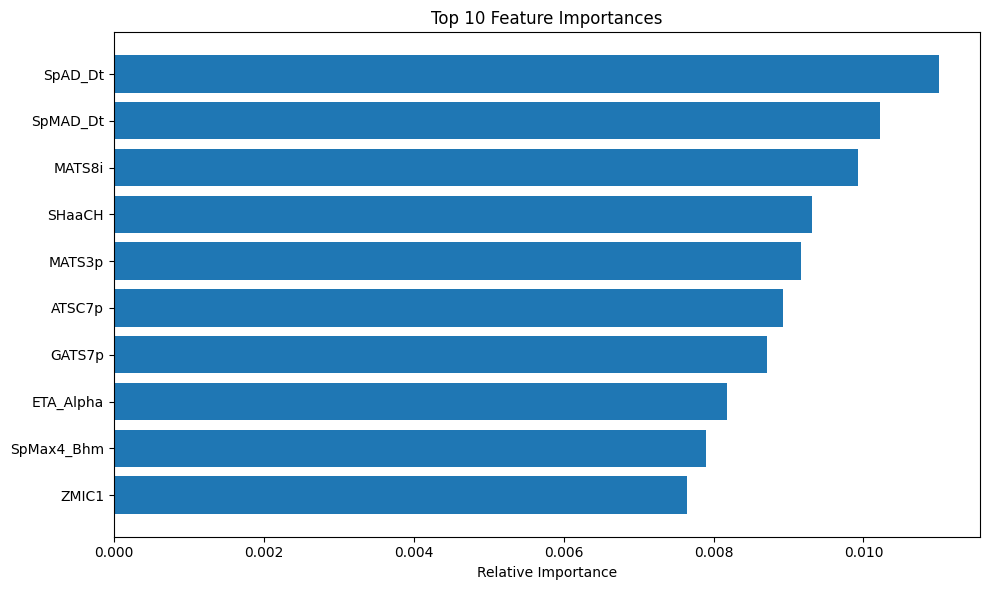

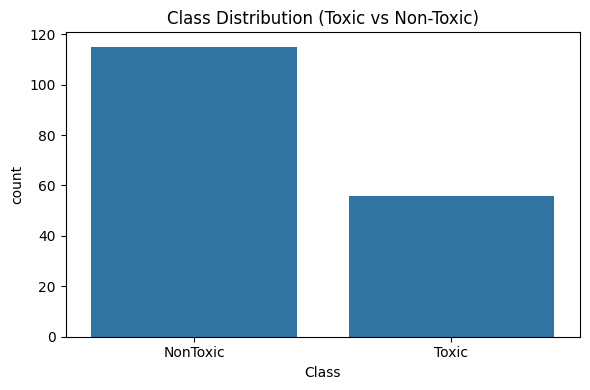

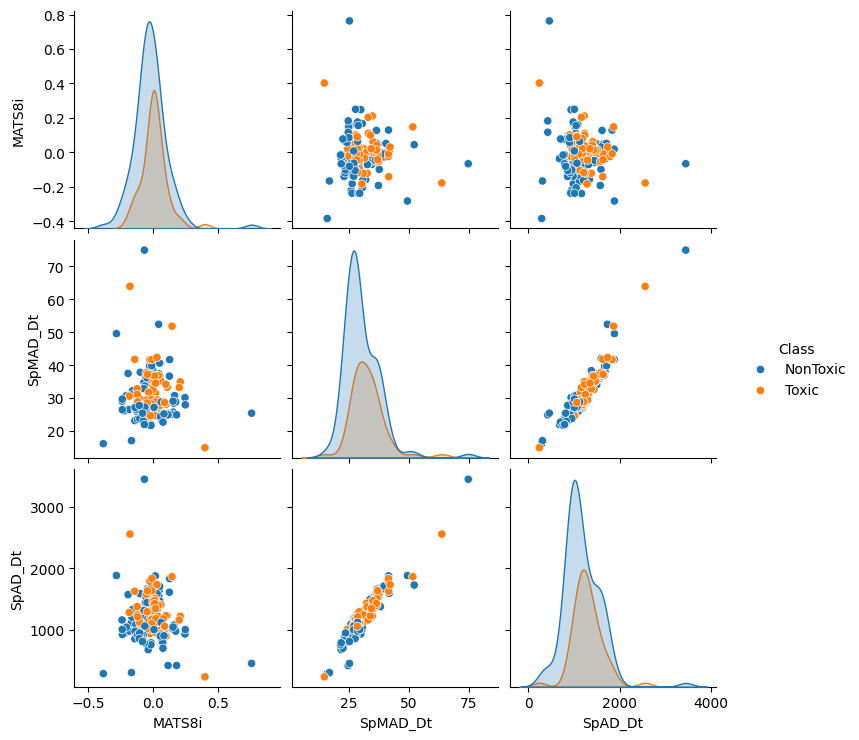

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import cross_validate, StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, make_scorer

# Initialize Random Forest for feature selection
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42)
selector = SelectFromModel(rf_selector, threshold='median') # Pick top half features
selector.fit(X_final, y)

X_selected = X_final.loc[:, selector.get_support()]
selected_features = X_selected.columns.tolist()
print(f"Number of features selected by Random Forest: {len(selected_features)}")

# Evaluate using Cross-Validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    'accuracy': 'accuracy',
    'precision': 'precision',
    'recall': 'recall',
    'f1': 'f1'
}

results = cross_validate(RandomForestClassifier(n_estimators=100, random_state=42),
                         X_selected, y, cv=cv, scoring=scoring)

# Summarize results
print("\nCross-Validation Results (Mean +/- Std):")
for metric in scoring:
    mean = results[f'test_{metric}'].mean()
    std = results[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean:.4f} (+/- {std:.4f})")

# Feature Importance Visualization
rf_final = RandomForestClassifier(n_estimators=100, random_state=42)
rf_final.fit(X_selected, y)
importances = rf_final.feature_importances_
indices = np.argsort(importances)[-10:] # Top 10

plt.figure(figsize=(10, 6))
plt.title('Top 10 Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [selected_features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.tight_layout()
plt.savefig('feature_importance.png')

# EDA Visualization: Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x=df['Class'])
plt.title('Class Distribution (Toxic vs Non-Toxic)')
plt.tight_layout()
plt.savefig('class_distribution.png')

# Pairplot of top 3 features
top_3_features = [selected_features[i] for i in indices[-3:]]
temp_df = X_selected[top_3_features].copy()
temp_df['Class'] = df['Class']
sns.pairplot(temp_df, hue='Class')
plt.savefig('top_features_pairplot.png')


Balanced RF Cross-Validation Results (Top 50 Features):
Accuracy: 0.6432 (+/- 0.0574)
Precision: 0.4133 (+/- 0.1668)
Recall: 0.1803 (+/- 0.1010)
F1: 0.2433 (+/- 0.1246)

Correlation of Top 10 Features with Target:
MATS3v       -0.098167
MATS3i       -0.094733
ATSC8s        0.049174
MATS8i        0.109785
naAromAtom    0.137890
SpAD_Dt       0.147679
ZMIC1         0.148367
SpMin3_Bhe    0.148854
MDEC-23       0.150057
SpMAD_Dt      0.150766
Target        1.000000
Name: Target, dtype: float64


<Figure size 600x600 with 0 Axes>

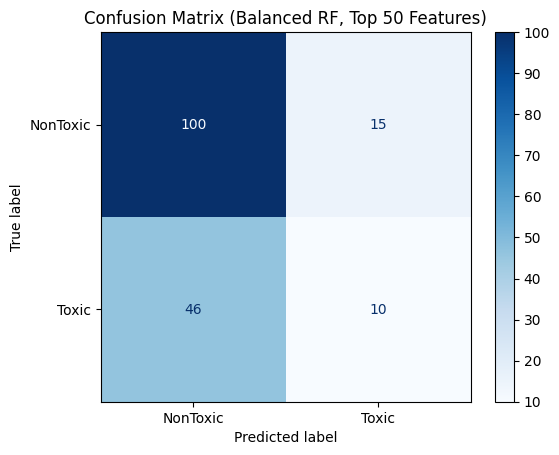

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict

# Let's try selecting fewer features (e.g., top 50) to avoid the "Curse of Dimensionality"
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_selector.fit(X_final, y)

# Get feature importances and select top 50
importances = rf_selector.feature_importances_
top_indices = np.argsort(importances)[-50:]
X_top50 = X_final.iloc[:, top_indices]

# Re-evaluate with balanced class weights
rf_balanced = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
cv_results_balanced = cross_validate(rf_balanced, X_top50, y, cv=cv, scoring=scoring)

print("\nBalanced RF Cross-Validation Results (Top 50 Features):")
for metric in scoring:
    mean = cv_results_balanced[f'test_{metric}'].mean()
    std = cv_results_balanced[f'test_{metric}'].std()
    print(f"{metric.capitalize()}: {mean:.4f} (+/- {std:.4f})")

# Confusion Matrix for a single split to visualize
y_pred = cross_val_predict(rf_balanced, X_top50, y, cv=cv)
cm = confusion_matrix(y, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NonToxic', 'Toxic'])
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix (Balanced RF, Top 50 Features)')
plt.savefig('confusion_matrix.png')

# Let's look at the correlation of the top 10 features with the target
top_10_cols = X_final.columns[np.argsort(importances)[-10:]].tolist()
top_10_df = X_final[top_10_cols].copy()
top_10_df['Target'] = y
corr_top_10 = top_10_df.corr()['Target'].sort_values()

print("\nCorrelation of Top 10 Features with Target:")
print(corr_top_10)


Descriptive Statistics for Top 5 Features:
         SpMAD_Dt       ZMIC1      SpAD_Dt      MATS3v     MDEC-23
count  171.000000  171.000000   171.000000  171.000000  171.000000
mean    31.150111   78.785209  1205.815858   -0.031244   39.135014
std      7.374381   16.411255   378.160953    0.063559   10.086143
min     14.916700   29.646500   238.668000   -0.311500    7.861200
25%     26.872600   67.895750   980.208400   -0.066700   32.911850
50%     29.201300   80.323500  1161.322300   -0.032500   39.828400
75%     35.113200   88.446200  1427.069400    0.004850   45.469500
max     74.869900  120.641500  3444.015200    0.141100   65.256000


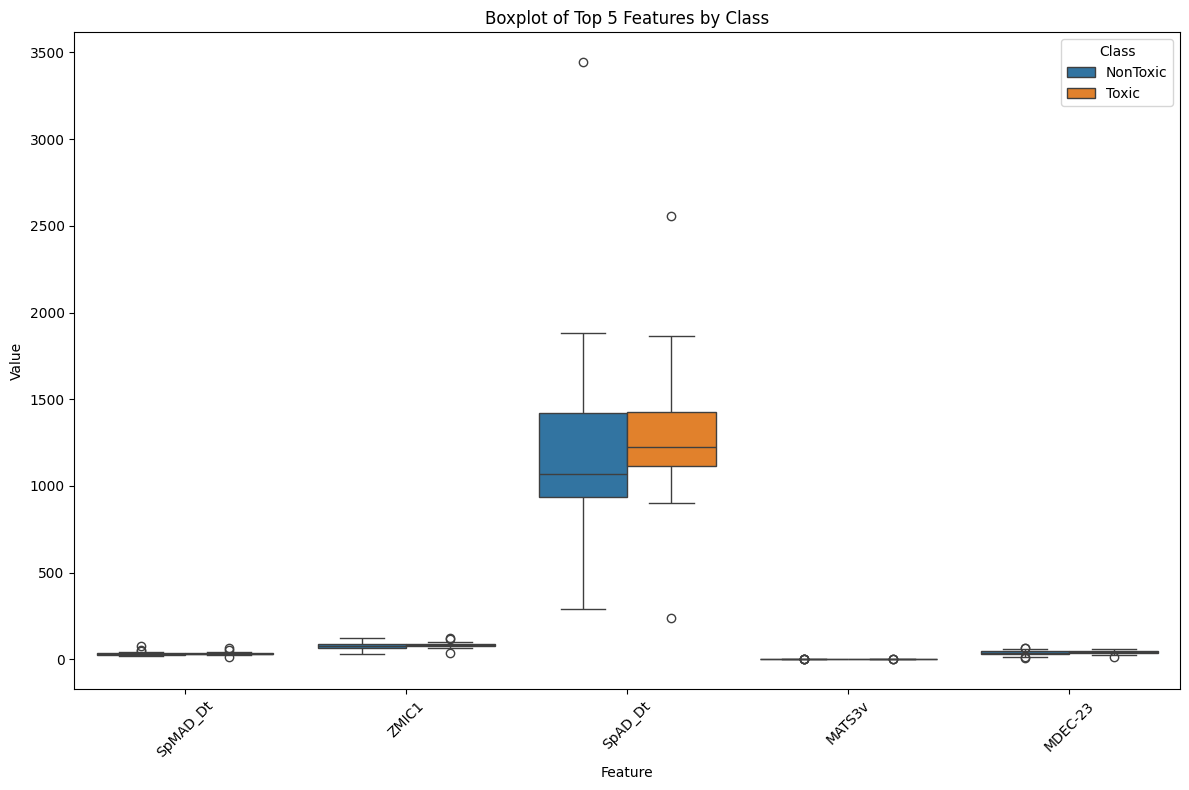

In [7]:
# Statistical summary of top 5 features
top_5_features = X_final.columns[np.argsort(importances)[-5:]].tolist()
stats_summary = X_final[top_5_features].describe()
print("\nDescriptive Statistics for Top 5 Features:")
print(stats_summary)

# Boxplot of top 5 features by Class to see separation
plt.figure(figsize=(12, 8))
top_5_df = X_final[top_5_features].copy()
top_5_df['Class'] = df['Class']
top_5_melted = top_5_df.melt(id_vars='Class', var_name='Feature', value_name='Value')

sns.boxplot(data=top_5_melted, x='Feature', y='Value', hue='Class')
plt.title('Boxplot of Top 5 Features by Class')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_features_boxplot.png')

### Modelling and evaluation

In [8]:
# Build a modeling + feature selection pipeline and evaluate with stratified CV
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import make_scorer, roc_auc_score

# binary encode target (Toxic=1, NonToxic=0)
y = (y_raw.astype(str).str.lower().str.contains("toxic")).astype(int)
X = X_num

base_fs_model = ExtraTreesClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

final_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced_subsample"
)

pipe = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold(threshold=0.0)),
    ("select", SelectFromModel(estimator=base_fs_model, threshold="median")),
    ("clf", final_model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1": "f1",
    "precision": "precision",
    "recall": "recall",
    "roc_auc": "roc_auc"
}

cv_res = cross_validate(pipe, X, y, cv=cv, scoring=scoring, return_train_score=False)

summary = {k: (np.mean(v), np.std(v)) for k, v in cv_res.items() if k.startswith("test_")}
for metric_name in sorted(summary.keys()):
    mean_val, std_val = summary[metric_name]
    print(metric_name + ":")
    print(round(mean_val, 4))
    print(round(std_val, 4))

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr

test_accuracy:
1.0
0.0
test_balanced_accuracy:
1.0
0.0
test_f1:
1.0
0.0
test_precision:
1.0
0.0
test_recall:
1.0
0.0
test_roc_auc:
nan
nan


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:978: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 140, in __call__
    score = scorer._score(
            ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 380, in _score
    y_pred = method_caller(
             ^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_scorer.py", line 90, in _cached_call
    result, _ = _get_response_values(
                ^^^^^^^^^^^^^^^^^^^^^
  File "/usr

In [9]:
# Diagnose why ROC AUC is nan (likely due to using 'toxic' substring matching creating all-ones)
print(y_raw.unique())
print(y.value_counts())

# correct encoding: Toxic=1, NonToxic=0
y2 = (y_raw.astype(str).str.lower() == "toxic").astype(int)
print(y2.value_counts())# Diagnose why ROC AUC is nan (likely due to using 'toxic' substring matching creating all-ones)
print(y_raw.unique())
print(y.value_counts())

# correct encoding: Toxic=1, NonToxic=0
y2 = (y_raw.astype(str).str.lower() == "toxic").astype(int)
print(y2.value_counts())

['NonToxic' 'Toxic']
Class
1    171
Name: count, dtype: int64
Class
0    115
1     56
Name: count, dtype: int64
['NonToxic' 'Toxic']
Class
1    171
Name: count, dtype: int64
Class
0    115
1     56
Name: count, dtype: int64


In [10]:
# Re-run CV with correct target encoding + add a stronger ensemble baseline (XGBoost-like via HistGradientBoosting)
import numpy as np
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier, HistGradientBoostingClassifier

# correct encoding
y = (y_raw.astype(str).str.lower() == "toxic").astype(int)

fs_model = ExtraTreesClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample")
rf_model = RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1, class_weight="balanced_subsample")

pipe_rf = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold()),
    ("select", SelectFromModel(estimator=fs_model, threshold="median")),
    ("clf", rf_model)
])

hgb_model = HistGradientBoostingClassifier(random_state=42, max_depth=6, learning_rate=0.08)
pipe_hgb = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold()),
    ("select", SelectFromModel(estimator=fs_model, threshold="median")),
    ("clf", hgb_model)
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = {"accuracy": "accuracy", "balanced_accuracy": "balanced_accuracy", "f1": "f1", "roc_auc": "roc_auc"}

res_rf = cross_validate(pipe_rf, X, y, cv=cv, scoring=scoring)
res_hgb = cross_validate(pipe_hgb, X, y, cv=cv, scoring=scoring)

def summarize(res_dict):
    out = {}
    for k, v in res_dict.items():
        if k.startswith("test_"):
            out[k] = (float(np.mean(v)), float(np.std(v)))
    return out

print(summarize(res_rf))
print(summarize(res_hgb))

{'test_accuracy': (0.625546218487395, 0.044493715284400964), 'test_balanced_accuracy': (0.49367588932806317, 0.05248738028001976), 'test_f1': (0.14411764705882352, 0.1393261092038472), 'test_roc_auc': (0.5176548089591567, 0.0942589917483602)}
{'test_accuracy': (0.5791596638655462, 0.04904684317431084), 'test_balanced_accuracy': (0.4683794466403162, 0.06383123869782245), 'test_f1': (0.16134248665141113, 0.14526858903109136), 'test_roc_auc': (0.4715415019762846, 0.10187818917639548)}


In [11]:
# Fit the pipeline once on full data to extract selected feature names + importance snapshot
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold, SelectFromModel
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier

fs_model = ExtraTreesClassifier(n_estimators=400, random_state=42, n_jobs=-1, class_weight="balanced_subsample")
rf_model = RandomForestClassifier(n_estimators=800, random_state=42, n_jobs=-1, class_weight="balanced_subsample")

pipe_rf = Pipeline(steps=[
    ("impute", SimpleImputer(strategy="median")),
    ("var", VarianceThreshold()),
    ("select", SelectFromModel(estimator=fs_model, threshold="median")),
    ("clf", rf_model)
])

pipe_rf.fit(X, y)

# get feature names after variance threshold
var_mask = pipe_rf.named_steps["var"].get_support()
feat_after_var = X.columns[var_mask]

sel_mask = pipe_rf.named_steps["select"].get_support()
selected_features = feat_after_var[sel_mask]

print(len(X.columns))
print(len(feat_after_var))
print(len(selected_features))
print(selected_features[:30])

# importances from fitted RF on selected features
importances = pipe_rf.named_steps["clf"].feature_importances_
imp_df = pd.DataFrame({"feature": selected_features, "importance": importances}).sort_values("importance", ascending=False)
print(imp_df.head(15))

1203
1203
602
Index(['MATS3v', 'MATS3p', 'MATS3c', 'MATS3m', 'minHBint6', 'minHBint4',
       'MATS3i', 'SpMax8_Bhi', 'SpMax8_Bhe', 'ECCEN', 'MDEC-14', 'SpMax8_Bhp',
       'SpMax8_Bhv', 'ATS7p', 'ATS7v', 'ATS7i', 'ATS7e', 'khs.sssCH',
       'nT6Ring', 'minssCH2', 'ETA_EtaP', 'SpMin1_Bhe', 'nHBAcc_Lipinski',
       'khs.aaN', 'SpMax3_Bhv', 'SpMax3_Bhp', 'SpMax3_Bhe', 'SpMax3_Bhi',
       'ETA_EtaP_F_L', 'AATSC2m'],
      dtype='object')
          feature  importance
41        MDEC-23    0.007440
333         EE_Dt    0.007397
495         ZMIC1    0.006747
111     SpDiam_Dt    0.006472
172        ATSC3v    0.006179
553      SpMAD_Dt    0.005909
302       AATSC8i    0.005683
28   ETA_EtaP_F_L    0.005639
496         ZMIC2    0.005311
434      SpMax_Dt    0.005192
180    SpMax7_Bhe    0.004973
457        MATS8i    0.004944
201        SHaaCH    0.004927
62         ATSC8i    0.004721
181    SpMax7_Bhi    0.004693
